# Projeto - Previsão de Risco de Crédito

## 1. Introdução

A análise de risco de crédito é um dos problemas mais clássicos e de maior impacto no setor financeiro. A concessão de crédito, seja para pessoas físicas ou jurídicas, é a base da atividade bancária, mas carrega consigo o risco inerente da inadimplência. Uma decisão de crédito equivocada pode levar a perdas financeiras significativas, enquanto uma política excessivamente conservadora pode resultar na perda de bons clientes e oportunidades de negócio valiosas.

Neste contexto, a ciência de dados emerge como uma ferramenta estratégica, permitindo que as instituições financeiras migrem de análises subjetivas e manuais para modelos preditivos objetivos, consistentes e escaláveis.

### 1.1. Descrição do problema

O problema central consiste em desenvolver um sistema inteligente capaz de classificar novos solicitantes de crédito em duas categorias: "bom risco" (provável que pague o empréstimo) e "mau risco" (provável que não pague o empréstimo).

Para esta análise, será utilizado conjunto de dados Statlog (German Credit Data), proveniente do repositório da UCI. Este dataset contém informações sobre 1.000 solicitantes de crédito na Alemanha, cada um descrito por 20 atributos, que incluem:

> Informações demográficas: idade, sexo, status civil.
> 
> Informações financeiras: status da conta corrente, histórico de crédito, valor e propósito do empréstimo, existência de poupança.
> 
> Informações profissionais e de moradia: tempo de emprego, tipo de trabalho, tipo de moradia.

A variável-alvo, risk, é binária, indicando se o cliente foi classificado como um bom ou mau pagador. Um desafio técnico relevante neste dataset é o desbalanceamento de classes, onde o número de "bons pagadores" é significativamente maior que o de "maus pagadores". Modelos treinados em dados desbalanceados podem se tornar tendenciosos, o que pode fazê-los performar mal ao identificar a classe minoritária, que é justamente a mais crítica para o negócio.

### 1.2. Objetivo

O objetivo principal deste projeto é construir um modelo de machine learning de classificação binária que preveja com alta acurácia e, mais importante, com alto poder de discriminação, a probabilidade de um solicitante de crédito se tornar inadimplente.

## 2. Configuração do Ambiente 

### 2.1 Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import skrub
import logging
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_ingestion import ingest_credit_data
from src import config

## 3. Carregamento dos Dados

### 3.1. Leitura do Conjunto de Dados

In [2]:
# Utiliza a URL definida no arquivo de configuração
url = config.GERMAN_CREDIT_ZIP_URL

# Carrega o arquivo através da URL
df = ingest_credit_data(url, True)

2025-11-07 19:09:05 - INFO - >>> INICIANDO O PIPELINE DE INGESTÃO DE DADOS <<<
2025-11-07 19:09:05 - INFO - Iniciando download de https://archive.ics.uci.edu/static/public/144/statlog+german+credit+data.zip
2025-11-07 19:09:06 - INFO - Arquivos extraídos com sucesso para: C:\Users\user\OneDrive\Documentos\HG\1.Projects\Dual\credit-risk\credit-risk-model\api-ml-python\data\raw
2025-11-07 19:09:06 - INFO - Procurando por arquivo '.data' em 'C:\Users\user\OneDrive\Documentos\HG\1.Projects\Dual\credit-risk\credit-risk-model\api-ml-python\data\raw'...
2025-11-07 19:09:06 - INFO - Arquivo alvo encontrado: 'german.data'
2025-11-07 19:09:06 - INFO - Arquivo renomeado para: 'credit_data.data'
2025-11-07 19:09:06 - INFO - Arquivo movido para: 'C:\Users\user\OneDrive\Documentos\HG\1.Projects\Dual\credit-risk\credit-risk-model\api-ml-python\data\processed'
2025-11-07 19:09:06 - INFO - Arquivo extra 'german.data-numeric' removido.
2025-11-07 19:09:06 - INFO - Arquivo extra 'german.doc' removido.
20

### 3.2. Visualização Inicial

#### Colunas Categóricas

In [54]:
# Gera um relatório exploratório apenas para as colunas categóricas do DataFrame
categorical_cols = df.select_dtypes(include=["object", "category"]).columns
df_numeric = df[categorical_cols]

logging.getLogger().setLevel(logging.ERROR)
skrub.TableReport(df_numeric).open()
logging.getLogger().setLevel(logging.INFO)


Processing column  13 / 13


#### Colunas Numéricas

In [55]:
# Gera um relatório exploratório apenas para as colunas numéricas do DataFrame
numeric_cols = df.select_dtypes(include=[np.number]).columns
df_numeric = df[numeric_cols]

logging.getLogger().setLevel(logging.ERROR)
skrub.TableReport(df_numeric).open()
logging.getLogger().setLevel(logging.INFO)


Processing column   8 / 8


## 4. Limpeza dos Dados

Verificação de dados ausentes, nulos e duplicados.

In [56]:
# Verifica o número de valores ausentes por coluna
missing_values = df.isnull().sum()
print("Valores ausentes por coluna:")
print(missing_values)

Valores ausentes por coluna:
checking_account_status       0
duration_in_month             0
credit_history                0
purpose                       0
credit_amount                 0
savings_account_bonds         0
present_employment_since      0
installment_rate_percent      0
personal_status_and_sex       0
other_debtors_guarantors      0
present_residence_since       0
property                      0
age_in_years                  0
other_installment_plans       0
housing                       0
number_of_existing_credits    0
job                           0
number_of_dependents          0
telephone                     0
foreign_worker                0
risk                          0
dtype: int64


In [57]:
# Conta o número total de valores NaN no DataFrame
num_nan = df.isnull().sum().sum()
print(f"Número total de valores NaN: {num_nan}")

# Conta o número total de valores nulos (incluindo None) no DataFrame
num_null = df.isna().sum().sum()
print(f"Número total de valores nulos: {num_null}")

Número total de valores NaN: 0
Número total de valores nulos: 0


In [58]:
# Verifica se existem valores duplicados
num_duplicates = df.duplicated().sum()
print(f"Número de linhas duplicadas: {num_duplicates}")

Número de linhas duplicadas: 0


In [59]:
# Exibe amostra de linhas duplicadas, caso exista
if num_duplicates > 0:
    print("Exemplo de linhas duplicadas:")
    display(df[df.duplicated()])

## 5. Análise da Variável Alvo

### 5.1. Mapeamento da Variável Alvo

Conversão dos valores originais (1, que representa 'bom risco', e 2, que representa 'mau risco') para o formato binário padrão 0 e 1, em que 0 representa o 'mau risco' e 1 representa o 'bom risco'.

In [60]:
# Exibe os valores únicos originalmente presentes na coluna 'risk'
print("Valores possíveis na variável 'risk' antes do mapeamento:")
print([int(x) for x in sorted(df['risk'].unique())])
print()
print("Legenda:")
print("1 = Bom risco")
print("2 = Mau risco")
print()

# Realiza o mapeamento: 1 (bom risco) -> 0, 2 (mau risco) -> 1
df['risk'] = df['risk'].map({1: 0, 2: 1})

# Exibe os valores únicos após o mapeamento
print("Valores possíveis na variável 'risk' após o mapeamento:")
print([int(x) for x in sorted(df['risk'].unique())])
print()
print("Legenda:")
print("0 = Mau risco")
print("1 = Bom risco")

Valores possíveis na variável 'risk' antes do mapeamento:
[1, 2]

Legenda:
1 = Bom risco
2 = Mau risco

Valores possíveis na variável 'risk' após o mapeamento:
[0, 1]

Legenda:
0 = Mau risco
1 = Bom risco


### 5.2. Análise da Distribuição

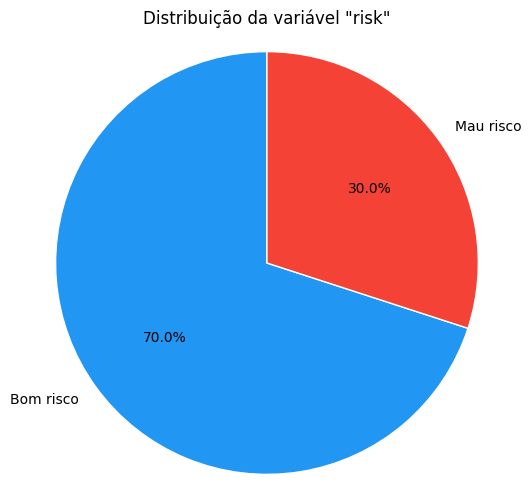

Distribuição:
risk
0    700
1    300
Name: count, dtype: int64

Legenda:
1 = Mau risco
0 = Bom risco


In [61]:
# Plota um gráfico de setores que mostra a distribuição das classes da variável alvo 'risk'.
risk_counts = df['risk'].value_counts().sort_index()  
labels = ['Mau risco' if v==1 else 'Bom risco' for v in risk_counts.index]
sizes = risk_counts.values
colors = ['#2196F3', '#F44336']

plt.figure(figsize=(6,6))
plt.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors, 
    wedgeprops={'edgecolor': 'white'}
)
plt.title('Distribuição da variável "risk"')
plt.axis('equal')
plt.show()

# Verifica a distribuição dos valores de da variável alvo'risk'.
print("Distribuição:")
print(df['risk'].value_counts().sort_index())
print()
print("Legenda:")
print("1 = Mau risco")
print("0 = Bom risco")


Com base nesses dados, percebe-se que, a classe majoritária, 'bom risco', compõe 70% das amostras, enquanto a classe minoritária, 'mau risco', representa os 30% restantes.

#### Análise do Desbalanceamento

Razão de desbalanceamento (Imbalance ratio):

IR = Classe majoritária / Classe minoritária = 700/300 = `2.33`

Esse valor indica um desbalanceamento leve, mas, ainda assim, é necessário uma atenção durante a modelagem para evitar um possível viés que favoreça a classe majoritária. 

##### Implicações para o negócio

- Aproximadamente 1 a cada 3 solicitantes de crédito é considerado 'mau risco'.
- A taxa de 30% é considerável, o que justifica o investimento em modelos preditivos para minimizar os erros de previsão do risco de crédito.

##### Implicações para a modelagem

- Apesar do desbalanceamento leve, será uma boa prática utilizar técnicas de balanceamento, para garantir que o modelo aprenda adequadamente os padrões da classe minoritária ('mau risco').
- Utilizar métricas alternativas para a avaliação do modelo.

#### Custos de Erros

- **Falso negativo**: Classificar um "mau pagador" como "bom pagador". Possui alto custo financeiro. 
- **Falso positivo**: Classificar um "bom pagador" como "mau pagador". Representa a perda de uma oportunidade de negócio.

É essencial que o modelo priorize a identificação correta de "maus pagadores", mesmo que isso signifique aumentar o número de falsos positivos.

## 6. Análise Univariada

### 6.1. Variáveis Numéricas

In [62]:
# DataFrame apenas com as colunas numéricas
numeric_cols_cfg = config.NUMERIC_COLUMNS
df_numeric = df[numeric_cols_cfg].copy()

# Visualização rápida (opcional)
display(df_numeric.head())

,duration_in_month,credit_amount,installment_rate_percent,present_residence_since,age_in_years,number_of_existing_credits,number_of_dependents
0,6,1169,4,4,67,2,1
1,48,5951,2,2,22,1,1
2,12,2096,2,3,49,1,2
3,42,7882,2,4,45,1,2
4,24,4870,3,4,53,2,2


### 6.1.1. Duração do Crédito (duration_in_month)

A variável `duration_in_month` representa o período, em meses, para o qual o cliente solicitou o crédito. Compreender a distribuição dessa variável é fundamental para identificar possíveis outliers, padrões ou faixas mais frequentes de prazo de empréstimo. Tendo em vista que prazos mais longos podem indicar maior risco para a instituição financeira, é importante verificar se há concentração de solicitações em determinados intervalos e se existem valores atípicos que possam impactar a modelagem.


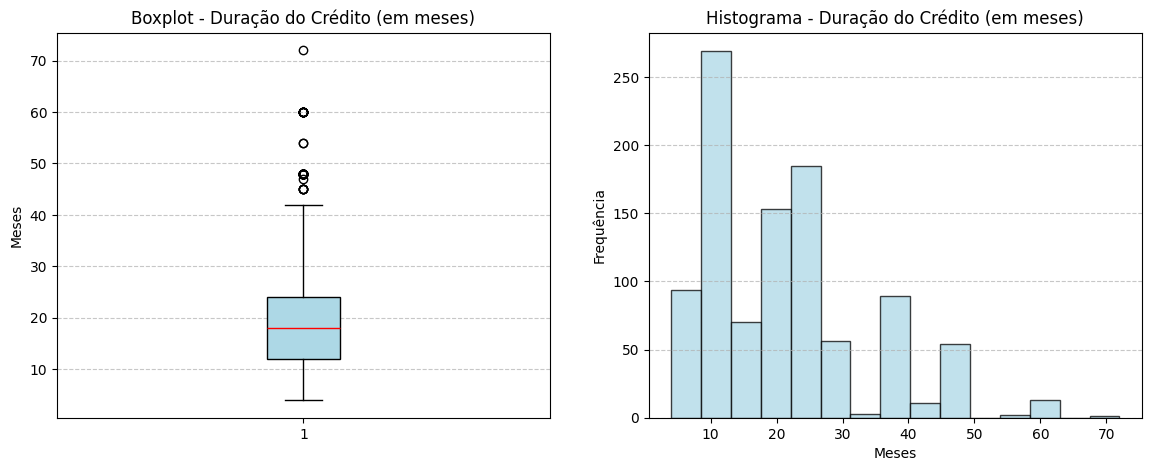

Limite superior para outliers de 'duration_in_month': 42.00 meses

Quantidade de valores acima do limite superior: 81 (8.10% do total)

Distribuição dos valores acima do limite superior:


duration_in_month
42    11
45     5
47     1
48    48
54     2
60    13
72     1
Name: count, dtype: int64

In [63]:
# Exibir o boxplot e histograma lado a lado usando subplots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot para 'duration_in_month'
axes[0].boxplot(
    df_numeric['duration_in_month'],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='red', linewidth=1) 
)
axes[0].set_title('Boxplot - Duração do Crédito (em meses)')
axes[0].set_ylabel('Meses')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Histograma para 'duration_in_month'
axes[1].hist(df_numeric['duration_in_month'], bins=15, color='lightblue', edgecolor='black', alpha=0.75)
axes[1].set_title('Histograma - Duração do Crédito (em meses)')
axes[1].set_xlabel('Meses')
axes[1].set_ylabel('Frequência')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Calcular o limite superior para identificar outliers
q1 = df_numeric['duration_in_month'].quantile(0.25)
q3 = df_numeric['duration_in_month'].quantile(0.75)
iqr = q3 - q1
superior_limit = q3 + 1.5 * iqr

print(f"Limite superior para outliers de 'duration_in_month': {superior_limit:.2f} meses")

# Exibir a concentração de valores acima do limite superior de forma percentual e absoluta
above_limit = df_numeric[df_numeric['duration_in_month'] >= superior_limit]['duration_in_month']
total = len(df)
above_quantity = above_limit.count()
percent = 100 * above_quantity / total

print(f"\nQuantidade de valores acima do limite superior: {above_quantity} ({percent:.2f}% do total)\n")
print("Distribuição dos valores acima do limite superior:")
display(above_limit.value_counts().sort_index())

A análise da distribuição da variável `duration_in_month`, baseada nos gráficos e nas informações acima, revela alguns pontos importantes:

**Boxplot**:
- 50% dos valores mais centrais da distribuição concentram-se entre, aproximadamente 12 e 24 meses (1 a 2 anos), indicando que a maioria dos créditos possuem um prazo relativamente curto a médio.
- A mediana de, aproximadamente, 18 meses, indica que metade dos clientes fazem solicitações de crédito com duração inferior a esse valor.
- Há uma presença significativa de outliers, sendo 81 observações acima de 42 meses, que correspondem a cerca de 8.10% da distribuição. Essa informação sugere um grupo substancial de clientes com créditos de prazos bem mais longos. 

**Histograma**:
- Existe uma concentração em prazos redondos (6, 12, 18, 24, 36, 48, 60), o que sugere a existência de produtos financeiros com prazos padronizados, que são oferecidos pelo banco.  
- Forte assimetria positiva (à direita), com concentração nos valores menores e cauda longa estendendo-se até 72 meses.
- Após 24 meses, a frequência passa a decrescer, com quedas mais acentuadas após 36 meses. 

 
**Implicações para o projeto:**
- Os outliers não devem ser removidos, haja visto que representam clientes com perfis de créditos legítimos, apesar de diferenciados, e que potencialmente estão associados a maior exposição ao risco ou valores de crédito mais elevados. 
- Será necessário investigar a relação entre os prazos longos (acima de 42 meses) e a taxa de inadimplência, bem como a correlação com o valor de crédito solicitado.


### 6.1.2. Quantidade de Crédito (credit_amount)

A variável `credit_amount` representa o valor total do crédito solicitado pelo cliente em uma determinada operação. Analisar a distribuição dessa variável é essencial para identificar a existência de outliers, padrões de concessão e faixas mais comuns de valor de crédito. Montantes de crédito mais elevados podem estar associados a maiores riscos e a diferentes perfis de clientes, sendo fundamental observar possíveis concentrações em certos intervalos, assim como valores atípicos extremos capazes de impactar as análises estatísticas e a modelagem preditiva.

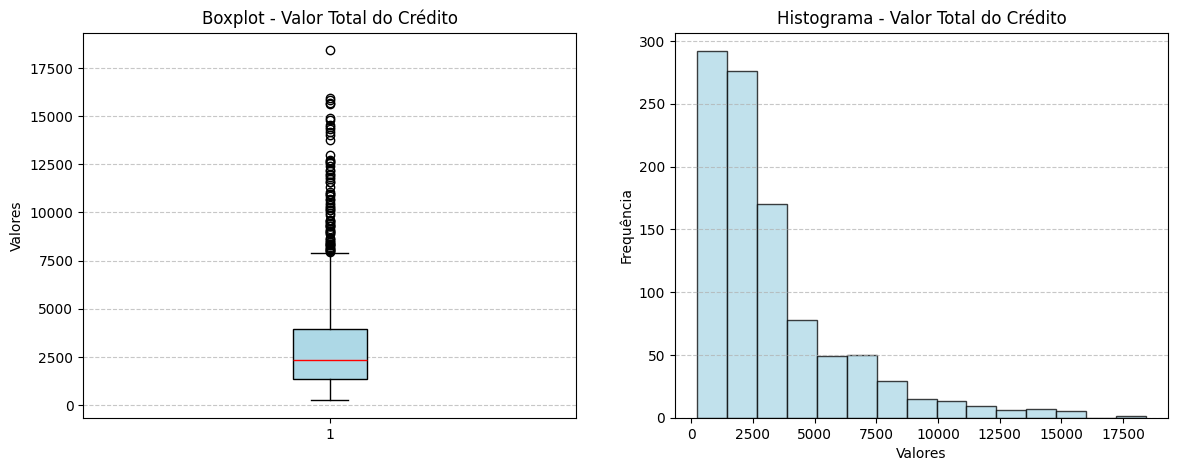

Limite superior para outliers de 'credit_amount': 7882.38

Quantidade de valores acima do limite superior: 72 (7.20% do total)

Valor mínimo dos outliers: 7966
Valor máximo dos outliers: 18424


In [64]:
# Boxplot e histograma lado a lado, já calculando o IQR e destacando informações de outliers

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot para 'credit_amount'
axes[0].boxplot(
    df_numeric['credit_amount'],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='red', linewidth=1)
)
axes[0].set_title('Boxplot - Valor Total do Crédito')
axes[0].set_ylabel('Valores')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Histograma para 'credit_amount'
axes[1].hist(df_numeric['credit_amount'], bins=15, color='lightblue', edgecolor='black', alpha=0.75)
axes[1].set_title('Histograma - Valor Total do Crédito')
axes[1].set_xlabel('Valores')
axes[1].set_ylabel('Frequência')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Cálculo do IQR e análise de outliers para 'credit_amount'
q1 = df_numeric['credit_amount'].quantile(0.25)
q3 = df_numeric['credit_amount'].quantile(0.75)
iqr = q3 - q1
superior_limit = q3 + 1.5 * iqr

print(f"Limite superior para outliers de 'credit_amount': {superior_limit:.2f}")

above_limit = df_numeric[df_numeric['credit_amount'] > superior_limit]['credit_amount']
total = len(df_numeric)
above_quantity = above_limit.count()
percent = 100 * above_quantity / total

print(f"\nQuantidade de valores acima do limite superior: {above_quantity} ({percent:.2f}% do total)\n")

if above_quantity > 0:
    min_outlier = above_limit.min()
    max_outlier = above_limit.max()
    print(f"Valor mínimo dos outliers: {min_outlier}")
    print(f"Valor máximo dos outliers: {max_outlier}")
else:
    print("Não há outliers acima do limite superior.")

Pontos importantes a serem considerados, evidenciados pelos gráficos e informações acima: 

- A grande maioria dos empréstimos está concentrada em valores abaixo de 5000. 
- A mediana está em torno de 2500.
- Existem 72 outliers acima do limite superior, com valores que variam de 7966 a 18424. 

**Implicações para o projeto**:

A hipótese de risco, neste caso, é saber se os outliers estão associados a um elevado potencial de inadimplência. É essencial a realização dessa análise em razão de, quanto maior o valor de crédito solicitado, maior será o prejuízo financeiro para o banco, caso o cliente seja inadimplente. 

Além disso, a forte assimetria dos dados (cauda longa à direita) sugere que, para certos algoritmos de machine learning, uma transformação pode ser necessária na etapa de pré-processamento para melhorar o desempenho do modelo.

### 6.1.3. Idade (age_in_years)
 
A variável `age_in_years` representa a idade do cliente em anos. Analisar a distribuição dessa variável é importante para identificar a presença de outliers, padrões etários predominantes e possíveis agrupamentos de faixas de idade entre os clientes. Perfis etários diferentes podem estar associados a diferentes riscos e necessidades de crédito, sendo essencial observar concentrações em determinados intervalos, assim como valores extremos que possam impactar as análises estatísticas e os modelos preditivos.

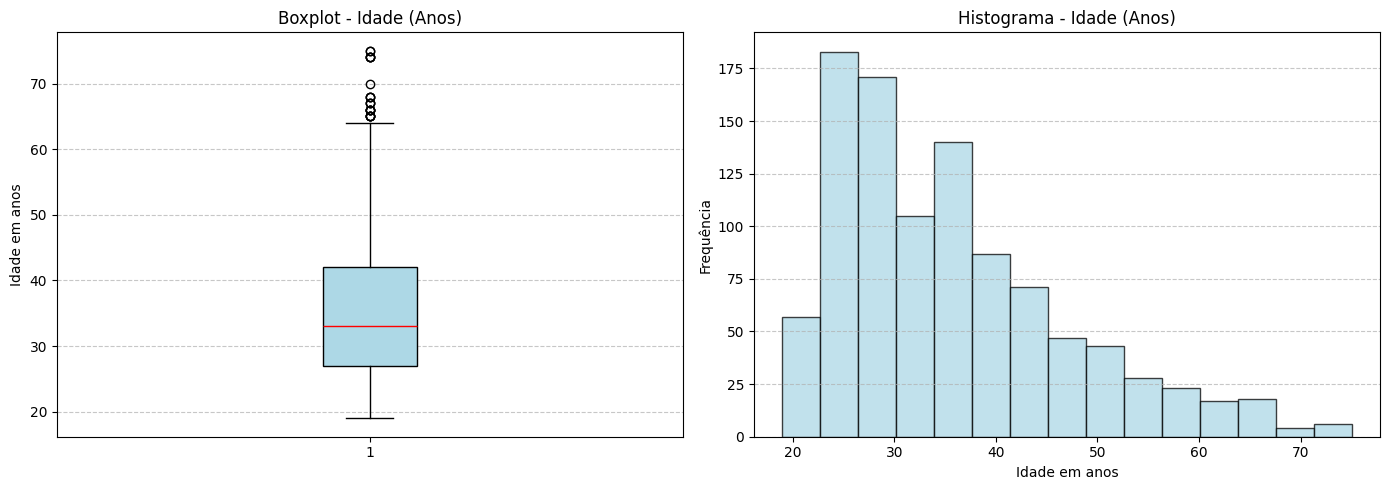

In [65]:
# Exibir o boxplot e histograma lado a lado usando subplots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot para 'age_in_years'
axes[0].boxplot(
    df_numeric['age_in_years'],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='red', linewidth=1) 
)
axes[0].set_title('Boxplot - Idade (Anos)')
axes[0].set_ylabel('Idade em anos')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Histograma para 'age_in_years'
axes[1].hist(df_numeric['age_in_years'], bins=15, color='lightblue', edgecolor='black', alpha=0.75)
axes[1].set_title('Histograma - Idade (Anos)')
axes[1].set_xlabel('Idade em anos')
axes[1].set_ylabel('Frequência')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

Com base nos gráficos, pode-se observar que:

- A distribuição das idades é assimétrica à direita, indicando que a base de solicitantes é predominantemente composta por clientes mais jovens.
- A maior concentração de clientes está na faixa dos 25 aos 40 anos, com a mediana situando-se em torno dos 33 anos.
- Existem alguns outliers identificados acima dos 65 anos, representando os clientes mais velhos, que são uma pequena minoria no conjunto de dados.

Implicações para o projeto:

A hipótese de risco a ser validada é se faixas etárias diferentes apresentam níveis de risco diferentes. Intuitivamente, clientes muito jovens (ex: abaixo de 27 anos) podem ter maior risco devido à menor estabilidade financeira, enquanto o grupo de meia-idade (o mais numeroso) pode ser o mais seguro. Essa assimetria e os diferentes "estágios de vida" sugerem que uma simples relação linear pode não ser suficiente, reforçando a importância de testar a criação de categorias de idade (age_category) durante a engenharia de atributos.

### 6.1.4. Percentual de Taxa de Parcelamento (installment_rate_percent)

A variável installment_rate_percent indica qual porcentagem da renda do cliente é destinada ao pagamento da prestação. É importante observar que essa variável não representa um valor exato, mas sim uma categoria de 1 a 4, onde cada número corresponde a uma faixa percentual. Valores mais altos (especialmente a categoria 4) apontam que o cliente compromete uma porção maior de sua renda com a dívida. Intuitivamente, quanto maior esse valor, maior o risco de inadimplência, pois a disponibilidade financeira do cliente torna-se mais restrita. Na análise, busca-se confirmar se o risco realmente aumenta do nível 1 para o 4.


C:\Users\user\AppData\Local\Temp\ipykernel_28276\590938791.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=installment_counts.index, y=installment_counts.values, palette="viridis")


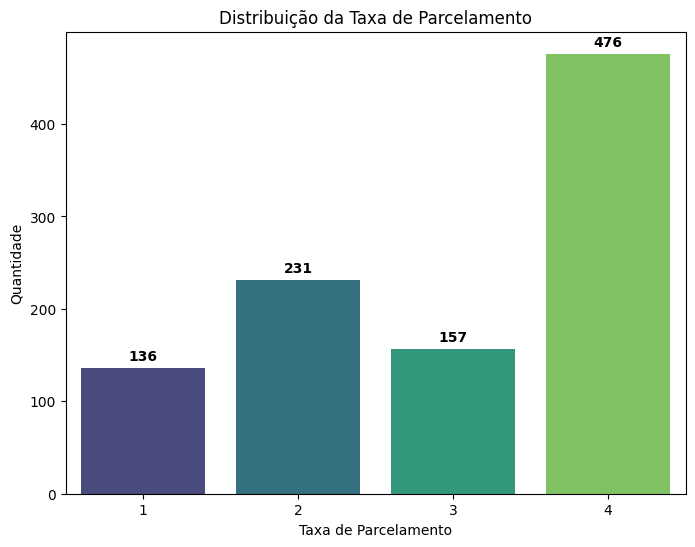

In [66]:
installment_counts = df_numeric['installment_rate_percent'].value_counts().sort_index()
plt.figure(figsize=(8,6))
ax = sns.barplot(x=installment_counts.index, y=installment_counts.values, palette="viridis")
ax.set_xlabel('Taxa de Parcelamento')
ax.set_ylabel('Quantidade')
ax.set_title('Distribuição da Taxa de Parcelamento')

for i, v in enumerate(installment_counts.values):
    ax.text(i, v + max(installment_counts.values)*0.01, str(v), ha='center', va='bottom', color='black', fontsize=10, fontweight='bold')

plt.show()

A partir do gráfico, evidencia-se os seguintes pontos: 

- **A categoria 4 é a mais comum**, representando cerca de 48% de todo o conjunto de dados. 
- **Sobre as demais categorias**, a categoria 2 é a segunda mais frequente (231 pessoas), seguida da categoria 3 (157 pessoas) e da categoria 1 (136 pessoas). Essas categorias representam clientes que comprometem faixas de renda mais baixas ou intermediárias. 

**Implicações sobre o negócio**:

Tendo em vista que a categoria 4 é a mais frequente no conjunto de dados e que ela representa a fatia dos clientes que possuem um 'fôlego' financeiro menor, isso pode sugerir um potencial risco de crédito elevado para esses clientes. 

**Implicações para o projeto**:

Existe uma hipótese a ser validada: *Essa grande quantidade de clientes na categoria 4 resulta em uma taxa de inadimplência maior?* 

### 6.1.5. Tempo de Residência no Endereço Atual (present_residence_since)

A variável `present_residence_since` indica há quanto tempo o cliente reside no endereço atual, sendo representada por valores inteiros de 1 a 4. Essa informação pode ser relevante para análise de risco de crédito, pois períodos mais longos de residência costumam estar associados a maior estabilidade financeira e menor probabilidade de inadimplência. Por outro lado, clientes com pouco tempo de residência podem indicar maior mobilidade ou instabilidade, fatores que podem aumentar o risco de concessão de crédito. 

C:\Users\user\AppData\Local\Temp\ipykernel_28276\188495197.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=present_residence_counts.index, y=present_residence_counts.values, palette="mako")


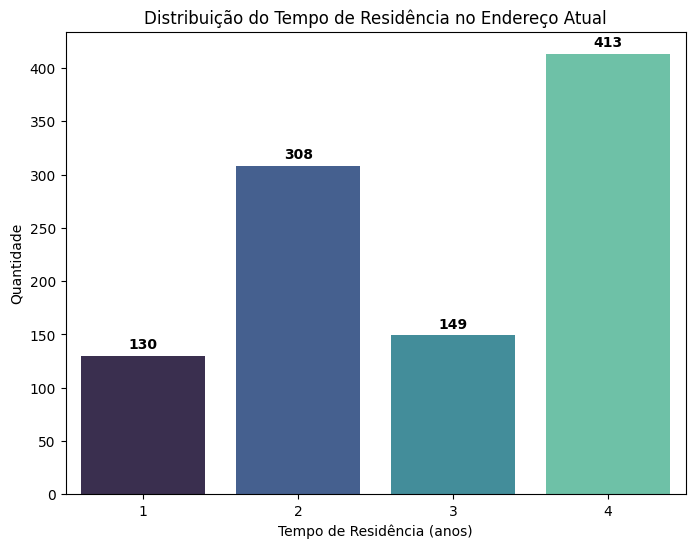

In [67]:
present_residence_counts = df_numeric['present_residence_since'].value_counts().sort_index()
plt.figure(figsize=(8,6))
ax = sns.barplot(x=present_residence_counts.index, y=present_residence_counts.values, palette="mako")
ax.set_xlabel('Tempo de Residência (anos)')
ax.set_ylabel('Quantidade')
ax.set_title('Distribuição do Tempo de Residência no Endereço Atual')

for i, v in enumerate(present_residence_counts.values):
    ax.text(i, v + max(present_residence_counts.values)*0.01, str(v), ha='center', va='bottom', color='black', fontsize=10, fontweight='bold')

plt.show()


Com base nas informações transmitidas pelo gráfico, pode-se afirmar que:

- A maioria dos clientes possui uma alta estabilidade residencial.
- A soma das categorias 3 e 4, que representam maior estabilidade, é 562. 
- A soma das categorias 1 e 2, que representam menor estabilidade, é 438. 


**Implicações para o projeto**:

Será necessário entender se uma maior estabilidade residencial se traduz em menor inadimplência. 

### 6.1.6. Número de Créditos Existentes no Banco (number_of_existing_credits)

A variável `number_of_existing_credits` representa a quantidade de créditos que o cliente já possui neste banco. Valores mais altos podem indicar maior exposição ao risco de endividamento, ao passo que valores mais baixos sugerem menor alavancagem. 


C:\Users\user\AppData\Local\Temp\ipykernel_28276\3197776783.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=credits_counts.index, y=credits_counts.values, palette="crest")


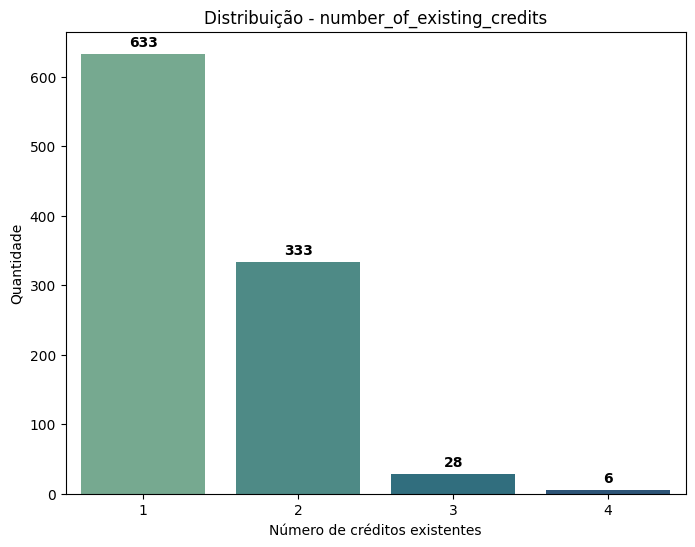

In [68]:
# Distribuição de number_of_existing_credits
credits_counts = df_numeric['number_of_existing_credits'].value_counts().sort_index()
plt.figure(figsize=(8,6))
ax = sns.barplot(x=credits_counts.index, y=credits_counts.values, palette="crest")
ax.set_xlabel('Número de créditos existentes')
ax.set_ylabel('Quantidade')
ax.set_title('Distribuição - number_of_existing_credits')

for i, v in enumerate(credits_counts.values):
    ax.text(i, v + max(credits_counts.values)*0.01, str(v), ha='center', va='bottom', color='black', fontsize=10, fontweight='bold')

plt.show()

Com base na distribuição observada, a maioria dos clientes concentra-se em 1 a 2 créditos existentes, o que sugere perfis com alavancagem moderada. Valores mais altos (3 ou 4) são menos frequentes e podem sinalizar maior exposição ao risco. 

**Implicações para o projeto**:

Deve-se verificar se o risco de inadimplência cresce com o número de créditos existentes.


### 6.1.7. Número de Dependentes (number_of_dependents)

A variável `number_of_dependents` representa quantas pessoas dependem financeiramente do cliente. Em geral, um número maior de dependentes pode pressionar o orçamento familiar, potencialmente elevando o risco de inadimplência.

C:\Users\user\AppData\Local\Temp\ipykernel_28276\2460235766.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=dep_counts.index, y=dep_counts.values, palette="flare")


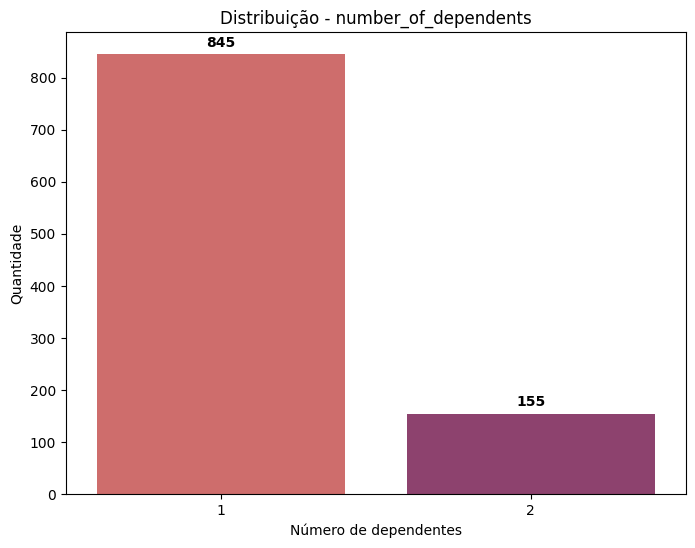

In [69]:
# Distribuição de number_of_dependents
dep_counts = df_numeric['number_of_dependents'].value_counts().sort_index()
plt.figure(figsize=(8,6))
ax = sns.barplot(x=dep_counts.index, y=dep_counts.values, palette="flare")
ax.set_xlabel('Número de dependentes')
ax.set_ylabel('Quantidade')
ax.set_title('Distribuição - number_of_dependents')

for i, v in enumerate(dep_counts.values):
    ax.text(i, v + max(dep_counts.values)*0.01, str(v), ha='center', va='bottom', color='black', fontsize=10, fontweight='bold')

plt.show()

O que se pode concluir com a análise do gráfico: 

A distribuição é bastante concentrada em poucos dependentes (1 ou 2), com a grande maioria dos clientes possuindo apenas 1 dependente (84,5%).  

**Implicações para o projeto**:

Será preciso avaliar se o aumento do número de dependentes está associado a maior probabilidade de inadimplência, além de investigar interações com `installment_rate_percent` e `credit_amount` para entender pressão simultânea de prestação e encargos familiares.


Correlação com Target (numéricas):
risk                          1.000000
duration_in_month             0.214927
credit_amount                 0.154739
installment_rate_percent      0.072404
present_residence_since       0.002967
number_of_dependents         -0.003015
number_of_existing_credits   -0.045732
age_in_years                 -0.091127
Name: risk, dtype: float64


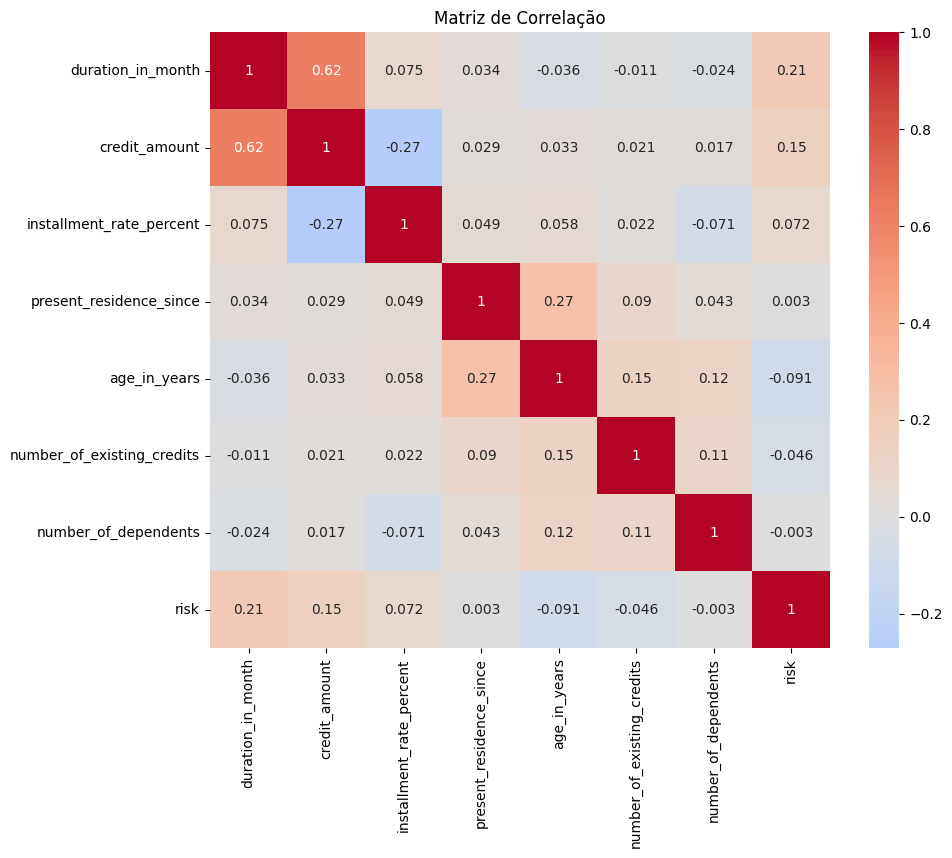


Chi-quadrado (categóricas):
                                chi2       p_value
checking_account_status   123.720944  1.218902e-26
credit_history             61.691397  1.279187e-12
savings_account_bonds      36.098928  2.761214e-07
purpose                    33.356447  1.157491e-04
property                   23.719551  2.858442e-05
present_employment_since   18.368274  1.045452e-03
housing                    18.199842  1.116747e-04
other_installment_plans    12.839188  1.629318e-03
personal_status_and_sex     9.605214  2.223801e-02
other_debtors_guarantors    6.645367  3.605595e-02
foreign_worker              5.821576  1.583075e-02
job                         1.885156  5.965816e-01
telephone                   1.172559  2.788762e-01

Top 10 Features (Random Forest):
                         feature  importance
1                  credit_amount    0.100365
0              duration_in_month    0.081173
4                   age_in_years    0.076434
10   checking_account_status_A14    0.05318

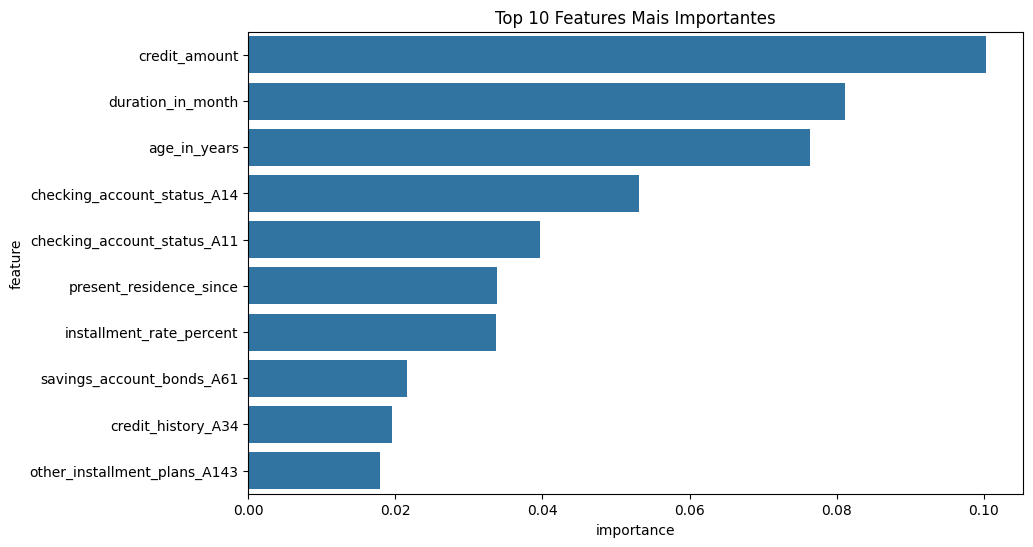

In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# 1. Correlação para variáveis numéricas
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numeric_cols].corr()

# Correlação com target
target_corr = correlation_matrix['risk'].sort_values(ascending=False)
print("Correlação com Target (numéricas):")
print(target_corr)

# Visualizar
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlação')
plt.show()

# 2. Chi-quadrado para variáveis categóricas
categorical_cols = df.select_dtypes(include=['object']).columns

chi2_scores = {}
for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df['risk'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    chi2_scores[col] = {'chi2': chi2, 'p_value': p_value}

chi2_df = pd.DataFrame(chi2_scores).T.sort_values('chi2', ascending=False)
print("\nChi-quadrado (categóricas):")
print(chi2_df)

# 3. Feature Importance com Random Forest
from sklearn.ensemble import RandomForestClassifier

X = pd.get_dummies(df.drop('risk', axis=1))
y = df['risk']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Features (Random Forest):")
print(feature_importance.head(10))

# Visualizar
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
plt.title('Top 10 Features Mais Importantes')
plt.show()

In [71]:
df['checking_account_status']

0      A11
1      A12
2      A14
3      A11
4      A11
      ... 
995    A14
996    A11
997    A14
998    A11
999    A12
Name: checking_account_status, Length: 1000, dtype: object

In [72]:
import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download("uciml/german-credit")

# Construir caminho correto do arquivo
file_path = os.path.join(path, 'german_credit_data.csv')

# Ler CSV
df2 = pd.read_csv(file_path)
df2.head(10)
df2.shape

(1000, 10)

In [73]:
df2.drop(columns=['Unnamed: 0'], inplace=True)
df2.head(10)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car
5,35,male,1,free,NaN,NaN,9055,36,education
6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment
7,35,male,3,rent,little,moderate,6948,36,car
8,61,male,1,own,rich,NaN,3059,12,radio/TV
9,28,male,3,own,little,moderate,5234,30,car


In [75]:
for column in df.columns:
    print(f"{column}: {df[column].unique()}\n")

checking_account_status: ['A11' 'A12' 'A14' 'A13']

duration_in_month: [ 6 48 12 42 24 36 30 15  9 10  7 60 18 45 11 27  8 54 20 14 33 21 16  4
 47 13 22 39 28  5 26 72 40]

credit_history: ['A34' 'A32' 'A33' 'A30' 'A31']

purpose: ['A43' 'A46' 'A42' 'A40' 'A41' 'A49' 'A44' 'A45' 'A410' 'A48']

credit_amount: [ 1169  5951  2096  7882  4870  9055  2835  6948  3059  5234  1295  4308
  1567  1199  1403  1282  2424  8072 12579  3430  2134  2647  2241  1804
  2069  1374   426   409  2415  6836  1913  4020  5866  1264  1474  4746
  6110  2100  1225   458  2333  1158  6204  6187  6143  1393  2299  1352
  7228  2073  5965  1262  3378  2225   783  6468  9566  1961  6229  1391
  1537  1953 14421  3181  5190  2171  1007  1819  2394  8133   730  1164
  5954  1977  1526  3965  4771  9436  3832  5943  1213  1568  1755  2315
  1412 12612  2249  1108   618  1409   797  3617  1318 15945  2012  2622
  2337  7057  1469  2323   932  1919  2445 11938  6458  6078  7721  1410
  1449   392  6260  7855  1680  

In [74]:
for column in df2.columns:
    print(f"{column}: {df2[column].unique()}\n")

Age: [67 22 49 45 53 35 61 28 25 24 60 32 44 31 48 26 36 39 42 34 63 27 30 57
 33 37 58 23 29 52 50 46 51 41 40 66 47 56 54 20 21 38 70 65 74 68 43 55
 64 75 19 62 59]

Sex: ['male' 'female']

Job: [2 1 3 0]

Housing: ['own' 'free' 'rent']

Saving accounts: [nan 'little' 'quite rich' 'rich' 'moderate']

Checking account: ['little' 'moderate' nan 'rich']

Credit amount: [ 1169  5951  2096  7882  4870  9055  2835  6948  3059  5234  1295  4308
  1567  1199  1403  1282  2424  8072 12579  3430  2134  2647  2241  1804
  2069  1374   426   409  2415  6836  1913  4020  5866  1264  1474  4746
  6110  2100  1225   458  2333  1158  6204  6187  6143  1393  2299  1352
  7228  2073  5965  1262  3378  2225   783  6468  9566  1961  6229  1391
  1537  1953 14421  3181  5190  2171  1007  1819  2394  8133   730  1164
  5954  1977  1526  3965  4771  9436  3832  5943  1213  1568  1755  2315
  1412 12612  2249  1108   618  1409   797  3617  1318 15945  2012  2622
  2337  7057  1469  2323   932  1919  2445 1